# Gradient Boosting Classifier

This notebook demonstrates training and evaluating a Gradient Boosting Classifier to predict the presence arsnenic based on item features including document type (`doc_type`), city of origin (`city`), country of origin (`country`), year of origin (`year`), room within storage location (`loc_room`), general storage location (`loc_gen`), and collection (`collection`). 

The pipeline includes data preprocessing, model training, cross-validation, and feature importance analysis.

The steps are the exact same as the pipline for Random Forest classifier, only difference is in the parameter tuning.

## 1. Import everything

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict, train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## 2. Load and explore the data

We begin by loading the dataset from an Excel file and preparing it for modeling. We print out the first 5 rows to showcase the structure of the dataset.

In [6]:
#Load dataset
df = pd.read_excel('new_result_v1.xlsx')


#df.head() #Prints first 5 rows of the DataFrame to view, this is commented out for the public version on github


## 3. Define Features and Target

We separate the target variable `result` from the features, and identify categorical and numeric columns.

In [13]:
#Define features and target
X = df.drop(columns=['result'])
y = df['result']

#Define categorical and numeric columns
categorical_cols = ['doc_type', 'city', 'country', 'loc_gen', 'loc_room', 'publisher', 'room_no', 'collection']
numeric_cols = ['year']

## 4. Preprocessing and Model Pipeline

We create a preprocessing pipeline using `ColumnTransformer` and `OneHotEncoder` for categorical features, then combine it with a `GradientBoostingClassifier`.


In [14]:
#Build preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

#Build the full pipeline, combine with classifier
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=1000,
        learning_rate=0.1,
        random_state=42,
        max_depth=3 
        #GB does not support class weight balance
    ))
])

## 5. Cross-Validation and Model Evaluation

We use Stratified K-Fold cross-validation to preserve class balance across folds, by ensuring each split have the same proportion as the overall dataset Multiple metrics are computed to evaluate model performance.

In [15]:
#Set up Stratified K-Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Train-test split (for feature importance extraction downstream)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 6. Classification Report

We generate predictions across all folds and compute a classification report showing per-class precision, recall, and F1-score. A discussion of these results can be found in Section 6.5 of the thesis.

In [16]:
#Get cross-validated predictions
y_pred_cv = cross_val_predict(clf_pipeline, X, y, cv=cv)

#Print per-class evaluation
print("\nPer-class evaluation report]:")
print(classification_report(y, y_pred_cv))


Per-class evaluation report]:
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       923
           1       0.72      0.63      0.67       495

    accuracy                           0.78      1418
   macro avg       0.77      0.75      0.75      1418
weighted avg       0.78      0.78      0.78      1418



## confusion matrix
To further visualise the classification results, the confusion matrix is plotted. Discussion (in comparsion to the random forest classifier)can also be found in Section 6.5.

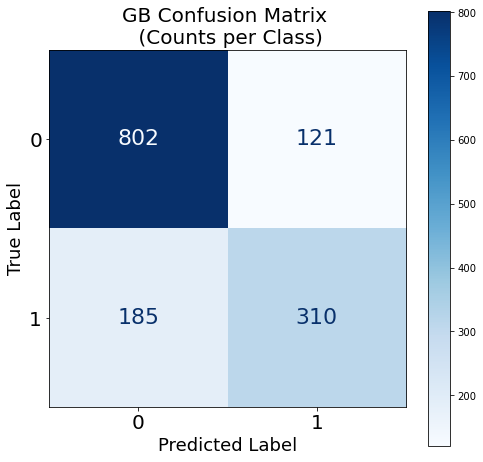

In [18]:
#Compute confusion matrix using cross-validated predictions
cm = confusion_matrix(y, y_pred_cv)

plt.figure(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())  # 'd' shows integer counts

#Add axis labels with larger fonts
plt.xlabel('Predicted Label', fontsize=18)
plt.ylabel('True Label', fontsize=18)

#Increase font size of numbers inside the matrix
ax = plt.gca()
for text in ax.texts:
    text.set_fontsize(22)

#Increase font size of tick labels (0 and 1)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.title('GB Confusion Matrix \n (Counts per Class)', fontsize=20)
#plt.savefig('GB_cm_counts.png', dpi=300, bbox_inches='tight')
plt.show()

# Feature Importance Analysis

## 7. Detailed Feature Importance

/Users/izzieho/opt/anaconda3/lib/python3.9/site-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


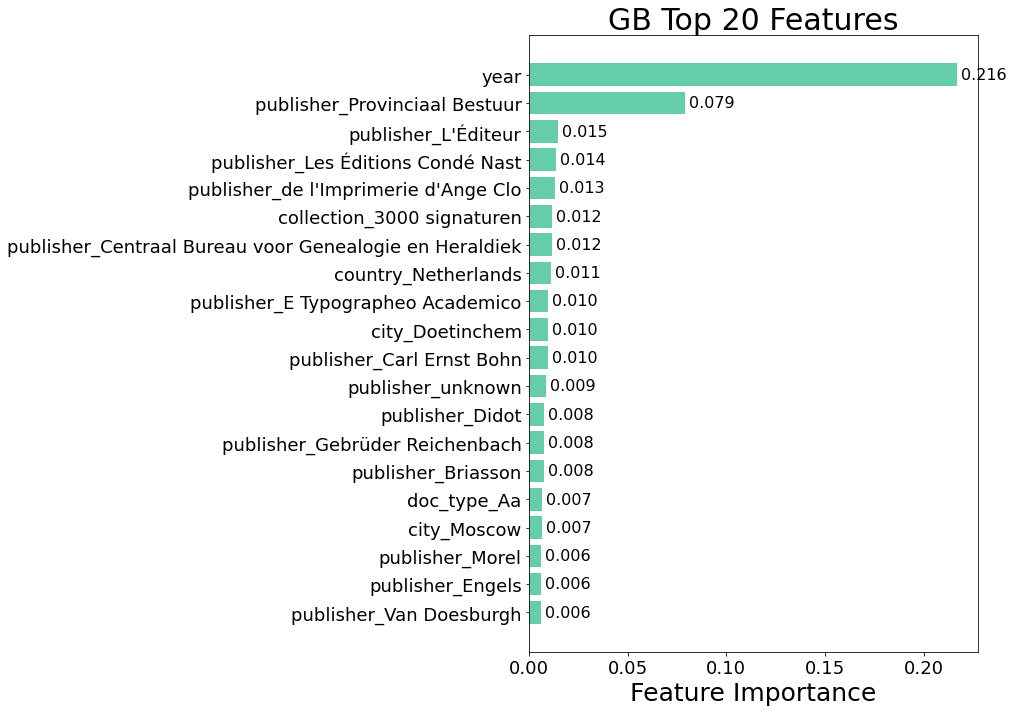

In [19]:
#Fit model on training data
clf_pipeline.fit(X_train, y_train)

#Extract trained model and preprocessor
model = clf_pipeline.named_steps['classifier']
preprocessor = clf_pipeline.named_steps['preprocessor']

#Fit preprocessor separately to get feature names
preprocessor.fit(X_train)

#Get encoded feature names
cat_transformer = preprocessor.named_transformers_['cat']
encoded_cat_features = cat_transformer.get_feature_names_out(categorical_cols)

#Get numeric features
remainder_cols = preprocessor.transformers_[-1][2]
numeric_features = [X.columns[i] if isinstance(i, int) else i for i in remainder_cols]

#Combine all feature names
all_feature_names = list(encoded_cat_features) + numeric_features

#Get feature importances
importances = model.feature_importances_

#Create DF for feature importance
feat_imp = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

#Plot
plt.figure(figsize=(14, 10))
bars = plt.barh(feat_imp['feature'][:20][::-1], feat_imp['importance'][:20][::-1], color='mediumaquamarine')
plt.xlabel("Feature Importance", fontsize=25)
plt.title("GB Top 20 Features", fontsize=30)
plt.yticks(fontsize=18)
plt.xticks(fontsize=18)

#Add importance scores at the end of bars
for bar in bars:
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.3f}', va='center', fontsize=16)

plt.tight_layout()
#plt.savefig('GB_features.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Grouped Feature Importance

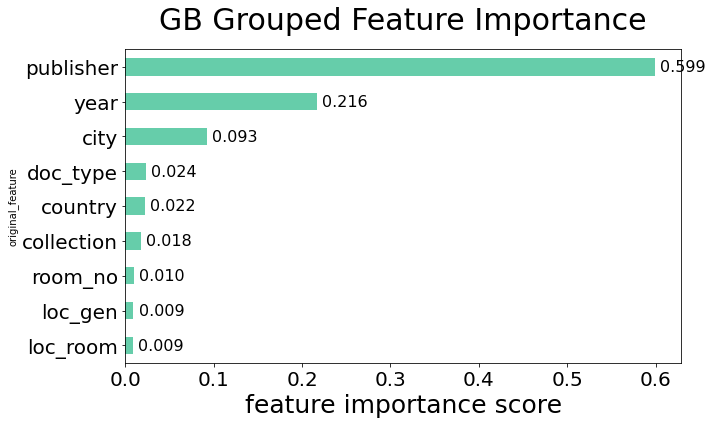

In [20]:
#Helper function to get group feature based on name
def get_original_col(feature_name):
    #Check for multi-word feature names first
    for col in categorical_cols + numeric_cols:
        if feature_name.startswith(col):
            return col
    return feature_name

feat_imp['original_feature'] = feat_imp['feature'].apply(get_original_col)

#Group by column
grouped_importance = feat_imp.groupby('original_feature')['importance'].sum().sort_values(ascending=False)

#Plot grouped feature importance
plt.figure(figsize=(10, 6))
ax = grouped_importance.plot(kind='barh', color='mediumaquamarine')
plt.xlabel("feature importance score", fontsize=25)
plt.title("GB Grouped Feature Importance", fontsize=30, pad=20)
plt.yticks(fontsize=20)
plt.xticks(fontsize=20)
plt.gca().invert_yaxis()

#Add importance values at the end of each bar
for i, v in enumerate(grouped_importance):
    ax.text(v + 0.01 * grouped_importance.max(), i, f"{v:.3f}", fontsize=16, va='center')

plt.tight_layout()
#plt.savefig('GB_grouped_features.png', dpi=300, bbox_inches='tight')
plt.show()